# Uygulamalı İstatistik Dersi 2025-2026

21 Kasım 2025 | 10. Hafta

[![Google Colab'de Aç](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mertssmnoglu/R/blob/main/uygulamali_istatistik_2025-2026/2025-11-21_uygulamali_istatistik_w10/2025-11-21_uygulamali_istatistik_w10.ipynb)

Analiz Künyesi:
1. Amacı
2. Örneklem
3. Varsayım
4. Uygulama
5. Yorum

## Bağımlı Örneklem T Testi

Farklı isimlerle de anılır:

Eşleştirilmiş Örneklem T Testi\
Tek Örneklem T Testi\
Paired Sample T Test\
One Sample T Test

### Amaç

Aynı grubun iki farklı ölçümünden elde edilen ortalamalar arasında fark olup olmadığını test etmek. Pre-Test ve Post-Test ölçümlerindeki ortalamaların karşılaştırılmasında kullanılır.

1. Ölçümler arasında fark olup olmadığını test etmek.
2. Bir doktorun uyguladığı tedavinin etkili olup olmadığını test etmek.
3. Bir eğitim programının etkili olup olmadığını test etmek.

### Hipotezler

H0: XOrtalama1 **=** XOrtalama2\
H1: XOrtalama1 **!=** XOrtalama2\
H1: XOrtalama1 **>** XOrtalama2\
H1: XOrtalama1 **<** XOrtalama2

### Varsayımlar

1. Fark değişkeni normal dağılım göstermelidir.

### Uygulama

#### Veri Seti

| -  | Ön Test | Son Test |
|----|---------|---------|
| 1  | 70      | 72      |
| 2  | 63      | 69      |
| 3  | 64      | 75      |
| 4  | 80      | 82      |
| 5  | 47      | 55      |
| 6  | 48      | 50      |
| 7  | 62      | 55      |
| 8  | 50      | 58      |
| 9  | 72      | 80      |
| 10 | 61      | 58      |

In [21]:
on_test <- c(70, 63, 64, 80, 47, 48, 62, 50, 72, 61)
son_test <- c(72, 69, 75, 82, 55, 50, 55, 58, 80, 58)

veri <- data.frame(on_test, son_test)

# # Yukarıdaki gibi tek tek yazmak istemezseniz, 'on_son_test.csv' dosyasını okuyup dataframe oluşturabilirsiniz.
# # Yorum satırını kaldırıp aşağıdaki kodu kullanabilirsiniz.
# veri <- read.csv("on_son_test.csv")


# Simetrik bir yapı olduğu için ön test'ten son test'in çıkarılmasıyla son test'ten ön test'in çıkarılması arasında fark yoktur.
fark <- veri$on_test - veri$son_test
# fark <- veri$son_test - veri$on_test

# Varsayımların test edilmesi
shapiro.test(fark)


	Shapiro-Wilk normality test

data:  fark
W = 0.92214, p-value = 0.3752


H0: Ön test ve son test ortalamaları arasında farklar normal dağılım göstermektedir.\
H1: Ön test ve son test ortalamaları arasında farklar normal dağılım göstermemektedir.

P değeri(0.3572) > α(0.05) olduğundan H0 reddedilemez. Yani, ön test ve son test arasındaki fark normal dağılım göstermektedir.

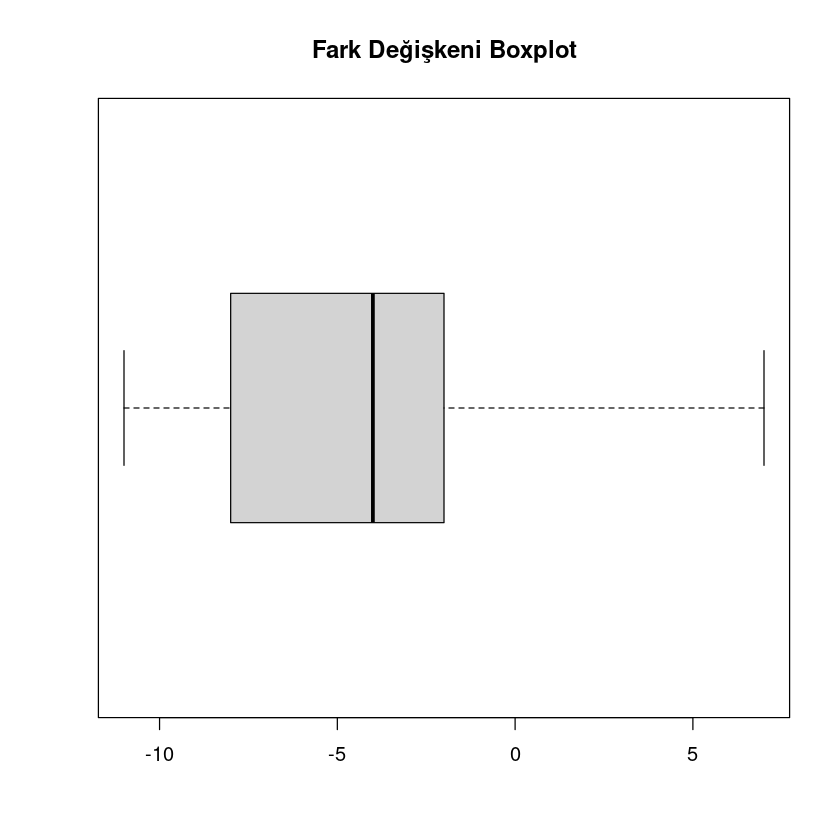

In [22]:
boxplot(fark, horizontal = TRUE, main = "Fark Değişkeni Boxplot")

In [23]:
t.test(
    veri$on_test,             # Ön test
    veri$son_test,            # Son test
    paired = TRUE,            # Bağımlı(Eşleştirilmiş) örneklem t testi
    alternative = "two.sided" # İki yönlü test
)


	Paired t-test

data:  veri$on_test and veri$son_test
t = -2.0899, df = 9, p-value = 0.0662
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -7.705005  0.305005
sample estimates:
mean difference 
           -3.7 


### Yorum

Ön test ve son test değerleri eşleştirilmiş örneklem t testi ile analiz edilmiştir. Normallik varsayımı Shapiro-Wilk testi ile test edilmiş ve verilerin normal dağıldığı görülmüştür (p > 0.05). Ortalama farkı T testi ile incelenmiş ve ortalamalar birbirinden farklı çıkmamıştır (t=-2.08, sd=9, p=0.067). Test öncesi ve test sonrası puanlar arasında istatistiksel olarak anlamlı bir fark bulunmamıştır. Uygulanan yöntem ortalamalarda anlamlı bir değişikliğe yol açmamıştır.

## Varyans Analizi

Analysis of Variance (ANOVA)

- [https://statsandr.com/blog/anova-in-r/](https://statsandr.com/blog/anova-in-r/)

### Amaç

3 veya daha fazla grubun ortalamalarının birbirinden farklı olup olmadığını test etmek için kullanılır.

1. Sosyoekonomik düzeylere göre gelir ortalamaları arasında fark var mıdır?

### Varsayımlar

Bağımsız örneklem T testindeki varsayımlarla benzerdir

1. Her bir grubun verileri normal dağılım göstermelidir.
2. Gruplar arası varyanslar homojen olmalıdır.

**F = t^2**

### Uygulama

In [ ]:
dv <- chickwts$weight # Dependent variable
iv <- chickwts$feed   # Independent variable

shapiro.test(dv)

# install.packages("rstatix")
library(rstatix)
# install.packages("dplyr")
library(dplyr)

chickwts %>% 
  group_by(feed) %>% 
  shapiro_test(weight)



	Shapiro-Wilk normality test

data:  dv
W = 0.97674, p-value = 0.2101


feed,variable,statistic,p
<fct>,<chr>,<dbl>,<dbl>
casein,weight,0.9166257,0.2591841
horsebean,weight,0.9375834,0.5264499
linseed,weight,0.9693128,0.9034734
meatmeal,weight,0.9791381,0.9611795
soybean,weight,0.9464029,0.5063768
sunflower,weight,0.9280884,0.3602904


P değeri 0.2101, α 0.05 olduğundan H0 reddedilemez. Yani, dv değişkeni normal dağılım göstermektedir.

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,5,0.7492639,0.5896095
,65,NA,NA


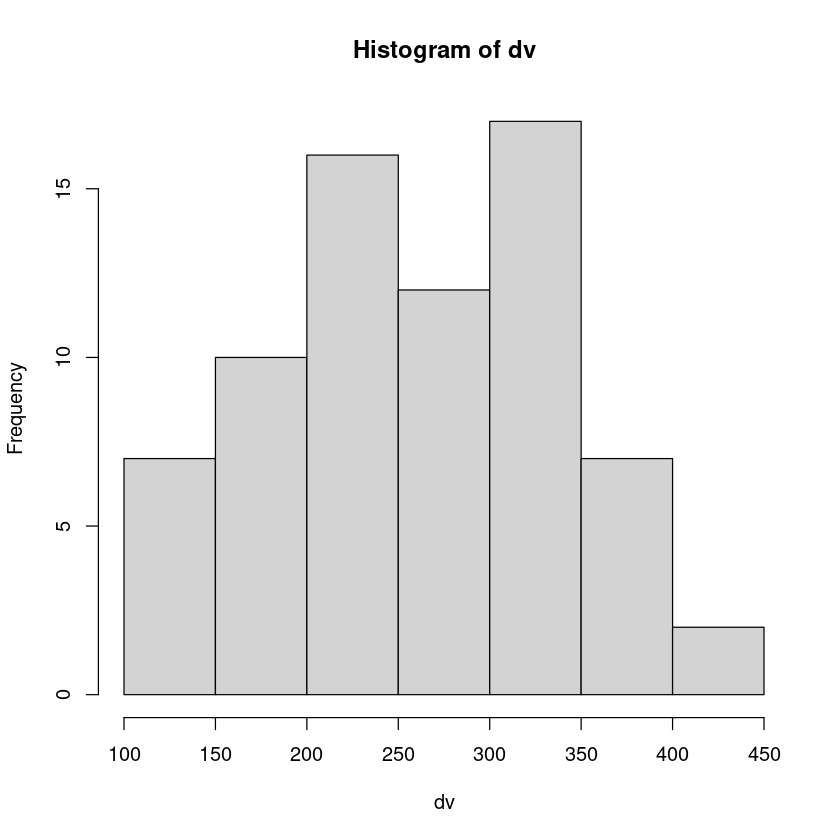

In [25]:
hist(dv)

# install.packages("car")
library(car)
leveneTest(dv ~ iv)

Levene testi sonucuna göre Pr(>F) = 0.5896, 0.05'ten büyük olduğundan gruplar arası varyanslar homojendir.


	One-way analysis of means

data:  dv and iv
F = 15.365, num df = 5, denom df = 65, p-value = 5.936e-10


            Df Sum Sq Mean Sq F value   Pr(>F)    
iv           5 231129   46226   15.37 5.94e-10 ***
Residuals   65 195556    3009                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

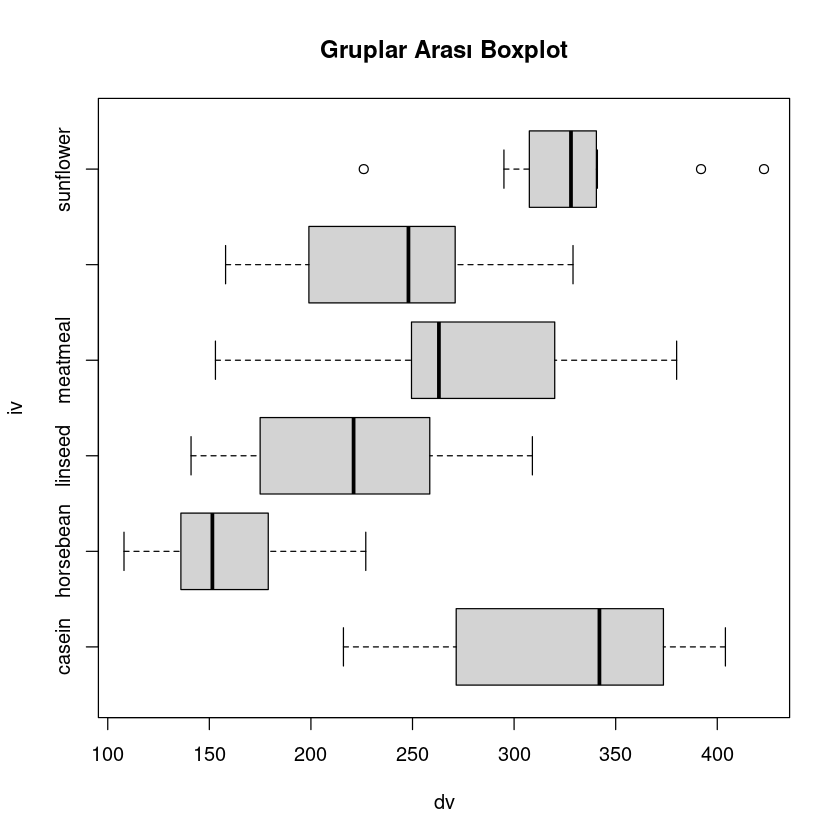

In [26]:
boxplot(dv ~ iv, horizontal = TRUE, main = "Gruplar Arası Boxplot")
oneway.test(dv ~ iv, var.equal = TRUE) # Varsayımlar sağlandığından var.equal = TRUE

aov1 <- aov(dv ~ iv)
summary(aov1)

In [27]:
TukeyHSD(aov1)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = dv ~ iv)

$iv
                           diff         lwr       upr     p adj
horsebean-casein    -163.383333 -232.346876 -94.41979 0.0000000
linseed-casein      -104.833333 -170.587491 -39.07918 0.0002100
meatmeal-casein      -46.674242 -113.906207  20.55772 0.3324584
soybean-casein       -77.154762 -140.517054 -13.79247 0.0083653
sunflower-casein       5.333333  -60.420825  71.08749 0.9998902
linseed-horsebean     58.550000  -10.413543 127.51354 0.1413329
meatmeal-horsebean   116.709091   46.335105 187.08308 0.0001062
soybean-horsebean     86.228571   19.541684 152.91546 0.0042167
sunflower-horsebean  168.716667   99.753124 237.68021 0.0000000
meatmeal-linseed      58.159091   -9.072873 125.39106 0.1276965
soybean-linseed       27.678571  -35.683721  91.04086 0.7932853
sunflower-linseed    110.166667   44.412509 175.92082 0.0000884
soybean-meatmeal     -30.480519  -95.375109  34.41407 0.739

Tukey sonuçlarını matris formatında görselleştirmek iyi bir yöntemdir.

| Grup | 1 | 2 | 3 | 4 | 5 | 6 |
|------|---|---|---|---|---|---|
| 1    |   |   |   |   |   |   |
| 2    |   |   |   |   |   |   |
| 3    |   |   |   |   |   |   |
| 4    |   |   |   |   |   |   |
| 5    |   |   |   |   |   |   |
| 6    |   |   |   |   |   |   |

Normallik:\
1.Shapiro-Wilk Testi

Varyans Homojenliği:\
1.Levene Testi
2.Bartlett Testi

Test Aşaması:\
1.aov Fonksiyonu\
2.anova.test Fonksiyonu

Karşılaştırma:\
1.Tukey HSD Testi

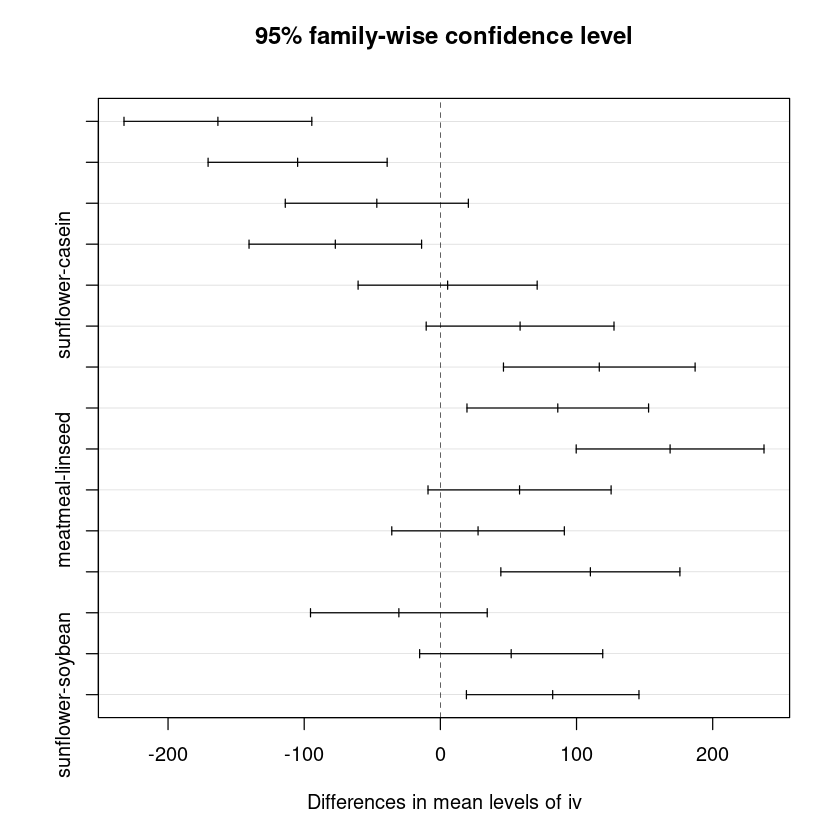

In [28]:
tukey_results <- TukeyHSD(aov1)
plot(tukey_results)